# Fixed-Knot LVG Smoothing Under Bid-Ask Constraints

**Purpose.** Starting from the original many-interval LVG calibration, this notebook holds every knot location nu fixed and changes only the diffusion coefficients sigma. The objective is to reduce

$$J(\theta)=\sum_j\left(C''(\nu_j^+)-C''(\nu_j^-)\right)^2,$$

while keeping model call prices inside all bid-ask quotes and preserving numerical static-arbitrage checks.

The modeled time value is

$$V_\theta(K)=C_\theta(K)-(S_0-K)^+,$$

and, away from the strike, $C_\theta''(K)=V_\theta''(K)$. Thus reducing jumps in $C''$ is equivalent to reducing the corresponding LVG time-value curvature jumps.

**What this establishes.** A reduction in J shows that the second-derivative jumps can be reduced by moving sigma values alone within the feasible quote region. It is evidence for a smoother admissible LVG curve, not proof of a unique or global optimum.

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from scipy.optimize import minimize

torch.set_default_dtype(torch.float64)

# Market constants used by the original LVG calibration.
S0 = 1271.87
Kbar = 2000.0

In [26]:
def calculate_J(R1, R2, S0, theta):
    """Return the sum of squared jumps in C'' for the fixed-knot LVG curve."""
    
    # 1. Slicing the parameters
    idx = 0
    nus1 = theta[idx : idx + R1]; idx += R1
    sigs1_raw = theta[idx : idx + R1]; idx += R1
    nus2 = theta[idx : idx + R2]; idx += R2
    sigs2_raw = theta[idx : idx + R2]; idx += R2

    nus1 = torch.cat([nus1, torch.tensor([S0])])

    nus2 = torch.cat([torch.tensor([S0]), nus2])

    # Enforce strict positivity on sigmas using softplus
    sigs1 = torch.nn.functional.softplus(sigs1_raw) + 1e-6
    sigs2 = torch.nn.functional.softplus(sigs2_raw) + 1e-6

    # =========================================================================
    # STAGE 1: Calculate Unit Base Coefficients (Setting lam1 = 1, lam2 = 1)
    # =========================================================================

    # Left Wing Unit Base
    c_v1_unit = []
    dist = nus1[1] - nus1[0]
    s0 = sigs1[0]
    c_v1_unit.append((-torch.exp(-dist/s0), torch.exp(dist/s0)))

    for j in range(R1 - 1):
        value_at_boundary = c_v1_unit[j][0] + c_v1_unit[j][1]
        slope_at_boundary = (1.0/sigs1[j]) * (-c_v1_unit[j][0] + c_v1_unit[j][1])
        dist = nus1[j+2] - nus1[j+1]
        c_v1_unit.append((0.5 * (value_at_boundary - sigs1[j+1]*slope_at_boundary) * torch.exp(-dist/sigs1[j+1]),
                          0.5 * (value_at_boundary + sigs1[j+1]*slope_at_boundary) * torch.exp(dist/sigs1[j+1])))

    # Right Wing Unit Base
    c_v2_unit = [None] * R2
    dist = nus2[-1] - nus2[-2]
    c_v2_unit[-1] = ((torch.exp(dist/sigs2[-1]), -torch.exp(-dist/sigs2[-1])))

    for j in range(R2 - 1, 0, -1):
        value_at_boundary = c_v2_unit[j][0] + c_v2_unit[j][1]
        slope_at_boundary = (1.0/sigs2[j]) * (-c_v2_unit[j][0] + c_v2_unit[j][1])
        dist = nus2[j] - nus2[j-1]
        c_v2_unit[j-1] = (0.5 * (value_at_boundary - sigs2[j-1]*slope_at_boundary) * torch.exp(dist/sigs2[j-1]),
                          0.5 * (value_at_boundary + sigs2[j-1]*slope_at_boundary) * torch.exp(-dist/sigs2[j-1]))

    # =========================================================================
    # STAGE 2: Evaluate Unit Wings at S0 and Solve for Viable Lambdas
    # =========================================================================
    
    # Left wing unit value at S0
    v1 = c_v1_unit[-1][0] + c_v1_unit[-1][1]

    # Right wing unit value at S0
    v2 = c_v2_unit[0][0] + c_v2_unit[0][1]

    # Derivatives at left and right of S0
    Dk_v1 = (1.0/sigs1[-1]) * (-c_v1_unit[-1][0] + c_v1_unit[-1][1])

    Dk_v2 = (1.0/sigs2[0]) * (-c_v2_unit[0][0] + c_v2_unit[0][1])

    # Define viable lambdas
    lam1 = v2 / (Dk_v1 * v2 - v1 * Dk_v2)

    lam2 = v1 / (Dk_v1 * v2 - v1 * Dk_v2)

    # =========================================================================
    # STAGE 3: Scale Unit Coefficients to Final Viable Coefficients
    # =========================================================================
    c_v1 = [(c1 * lam1, c2 * lam1) for (c1, c2) in c_v1_unit]
    c_v2 = [(c1 * lam2, c2 * lam2) for (c1, c2) in c_v2_unit]

    # c_v2[0][0] + c_v2[0][1] is the model time value at spot.

    # =========================================================================
    # STAGE 4: Calculate Smoothness Jumps
    # =========================================================================
    jumps = []

    # Internal Left Wing Jumps
    for j in range(R1 - 1):
        v_sec_left = (1.0/sigs1[j]**2) * (c_v1[j][0] + c_v1[j][1])
        dist = nus1[j+2] - nus1[j+1]
        v_sec_right = (1.0/sigs1[j+1]**2) * (c_v1[j+1][0]*torch.exp(dist/sigs1[j+1]) +
                                            c_v1[j+1][1]*torch.exp(-dist/sigs1[j+1]))
        jumps.append(v_sec_right - v_sec_left)

    # Junction Jump at x_strike
    v_sec_v1_strike = (1.0/sigs1[-1]**2) * (c_v1[-1][0] + c_v1[-1][1])
    v_sec_v2_strike = (1.0/sigs2[0]**2) * (c_v2[0][0] + c_v2[0][1])
    
    jumps.append(v_sec_v2_strike - v_sec_v1_strike)

    # Internal Right Wing Jumps
    for j in range(R2 - 1):
        v_sec_right = (1.0/sigs2[j+1]**2) * (c_v2[j+1][0] + c_v2[j+1][1])
        dist = nus2[j+1] - nus2[j]
        # Interval j is governed by sigs2[j] when evaluated at its right endpoint.
        v_sec_left = (1.0/sigs2[j]**2) * (c_v2[j][0]*torch.exp(-dist/sigs2[j]) +
                                            c_v2[j][1]*torch.exp(dist/sigs2[j]))
        jumps.append(v_sec_right - v_sec_left)

    j_val = torch.sum(torch.stack(jumps) ** 2)
    return j_val, lam1, lam2

## 1. Market Quote Data

The quote file contains strike, ask, and bid call prices. These quotes define the hard feasible band: any smoothed LVG curve must stay between the bid and ask at every quoted strike.

In [27]:
# Load call bid/ask quotes. File layout: strike, ask, bid.
quotes = pd.read_csv(
    "Quotes.csv",
    header=None,
    names=["K", "ask", "bid"],
).sort_values("K").reset_index(drop=True)

K_q = quotes["K"].to_numpy(dtype=float)
bid_q = quotes["bid"].to_numpy(dtype=float)
ask_q = quotes["ask"].to_numpy(dtype=float)

print("Number of quoted strikes:", len(K_q))
print("Quote strike range:", K_q.min(), "to", K_q.max())

Number of quoted strikes: 50
Quote strike range: 1103.9 to 1388.7


## 2. Full Fixed-Knot Baseline and Gradient

The arrays below are the original LVG calibration results, written explicitly in ordinary strike order. The left knots increase toward S0; the right knots increase outward from S0. This keeps the notebook self-contained and makes the starting point inspectable.

The optimization variable is

$$\theta=(\nu_{L},\; s_{L},\; \nu_{R},\; s_{R}),$$

where "s" is a raw parameter and $\sigma=\operatorname{softplus}(s)+10^{-6}>0$. All nu locations remain fixed. Only the sigma parameters are later adjusted to reduce $J$.


### Coefficient recursion used by calculate_J

On interval $j$, the LVG time value is represented locally as a pair of exponentials. At an interval boundary, the code stores two quantities: the value and slope passed from the previous interval,

$$P_j=a_j+b_j,$$

$$S_j=\frac{-a_j+b_j}{\sigma_j}.$$

To continue the same value and first derivative into the next interval, its new coefficients satisfy

$$a_{j+1}=\frac{1}{2}\left(P_j-\sigma_{j+1}S_j\right)e^{-h_{j+1}/\sigma_{j+1}},$$

$$b_{j+1}=\frac{1}{2}\left(P_j+\sigma_{j+1}S_j\right)e^{h_{j+1}/\sigma_{j+1}},$$

where $h_{j+1}$ is the distance across the next interval. The code calls these quantities value_at_boundary, slope_at_boundary, and dist.

The right wing is constructed inward from its far endpoint. When curvature is evaluated at an internal right-wing knot, the interval immediately to the left of that knot uses its own $\sigma_j$; this is the corrected indexing implemented in calculate_J.

In [28]:
def inverse_softplus(values, eps=1e-6):
    """Map positive diffusion coefficients to calculate_J's raw sigma coordinates."""
    adjusted = np.asarray(values, dtype=float) - eps
    if np.any(adjusted <= 0.0):
        raise ValueError("Every sigma must exceed the softplus epsilon.")
    # Stable inverse of softplus: log(exp(x) - 1), without evaluating exp on large values.
    raw = np.empty_like(adjusted)
    large = adjusted > 30.0
    raw[large] = adjusted[large] + np.log1p(-np.exp(-adjusted[large]))
    raw[~large] = np.log(np.expm1(adjusted[~large]))
    return raw


# Original LVG output, stored explicitly in ordinary increasing strike coordinates.
nu1_fixed = np.array([0, 985.8952130330157, 1103.9, 1105.6299717509714, 1108.9, 1110.9261114114317, 1113.9, 1116.0803462760916, 1118.9, 1121.217532062242, 1123.9, 1126.4524566940233, 1128.9, 1131.482542383951, 1133.9, 1136.5181574323626, 1138.9, 1141.5955696582002, 1143.9, 1146.6439410206626, 1148.9, 1151.6955052869373, 1153.9, 1156.7899943184998, 1158.9, 1161.6254606809712, 1163.9, 1166.5610218554195, 1168.9, 1171.459730260086, 1173.9, 1176.4403363141735, 1178.9, 1181.615546573849, 1183.9, 1186.6888172217348, 1188.9, 1191.7378244235415, 1193.9, 1196.5483693501587, 1198.8, 1201.5325443234078, 1203.8, 1206.5944516093734, 1208.8, 1211.4560716332721, 1213.8, 1216.4902257056644, 1218.8, 1221.5020603603978, 1223.8, 1226.3861829743955, 1228.8, 1231.2336479134826, 1233.8, 1236.1780621637572, 1238.8, 1241.7477258299014, 1243.8, 1247.0561689330698, 1248.8, 1251.2009300066638, 1253.8, 1256.2167752285077, 1258.8, 1261.4846983461696, 1263.8, 1265.7099860650808, 1268.8, 1270.5770900753105], dtype=float)
sigma1_base = np.array([610.4320996213446, 164.04874695079099, 21.410699478563217, 41.036799095433764, 32.59140099151007, 48.77559067919313, 42.2176372999541, 55.823566769595985, 51.211167181688566, 60.691607330511374, 59.950820637770775, 58.898463641159154, 61.253284806200256, 58.77606559998955, 61.9431978849179, 57.790240203069374, 62.2779153688338, 54.621537161593736, 60.38808834808558, 50.96497274766389, 57.49812984113923, 46.576659253726845, 54.080819207223875, 40.60311710082493, 46.79656147874567, 40.230053767550686, 44.17878499997829, 40.0738197788728, 42.59425882166232, 41.97429249407287, 43.554019179773334, 43.64066412990515, 46.68459597597928, 40.66643248490499, 45.74533322390213, 37.58570160756966, 43.36876861252296, 34.281419881606425, 38.63837902433531, 34.11699307804324, 38.33534468465065, 33.11788846662374, 37.54304297301797, 30.8995436545175, 34.629132576982585, 31.932382438352974, 34.99302768634262, 31.44000481459117, 34.80339761657143, 31.011124152999194, 33.67039062291056, 32.963580616942636, 33.88070107871873, 37.490458108901564, 36.9523875799828, 42.71457754035583, 46.473166992677335, 33.8545330176666, 43.67858033724246, 24.46553767335429, 29.27267842043444, 33.253868886417095, 32.860201483329625, 36.87919843993161, 38.56770262319378, 34.89031672560033, 32.336062185014455, 54.86203086146442, 42.54094598147429, 31.82466458162184], dtype=float)
nu2_fixed = np.array([1272.6042131350682, 1273.8, 1277.3405408056378, 1278.8, 1281.2353139855318, 1283.8, 1286.1696012675789, 1288.8, 1291.2560021979807, 1293.8, 1296.2794535546955, 1298.8, 1301.213819395613, 1303.7, 1306.2617186435, 1308.7, 1311.232700889095, 1313.7, 1316.810048833819, 1323.7, 1327.0068556961314, 1333.7, 1336.0240360741054, 1338.7, 1343.4698860472697, 1353.7, 1356.277830214803, 1358.7, 1361.5021167401464, 1363.7, 1377.3378359299822, 1388.7, 1503.7243622969859, 2000.0], dtype=float)
sigma2_base = np.array([24.02631471182734, 38.31350500726014, 64.22160217291687, 24.945880842361603, 31.475272346451945, 31.167940240782592, 29.04149431455202, 30.22926871363152, 28.245473181139502, 27.3473961133823, 26.078699124964757, 24.718907886876814, 23.35903470115683, 22.454368334929534, 22.002320937211316, 19.569326547161026, 19.315256975829875, 17.756271425921597, 19.392408982133873, 39.61543966355491, 26.387286176796366, 49.89596975113815, 28.527769674700764, 31.874820986884167, 41.72362039958813, 83.04797290752168, 40.34143759307382, 37.0089135084597, 39.353339426345215, 30.273572809409785, 73.52830072545393, 57.33057445441953, 169.4372302588361, 313.0441713343745], dtype=float)

def build_full_theta(nu1_fixed, sigma1_base, nu2_fixed, sigma2_base, S0):
    """Construct theta from fixed ordinary-strike knots and baseline sigmas."""


    # dont necessarily need these since we already have things in place to handle this in calculate_J, but good to check that the inputs are consistent with the original LVG output.
    if len(nu1_fixed) != len(sigma1_base) or len(nu2_fixed) != len(sigma2_base):
        raise ValueError("Each fixed interval knot must have one corresponding sigma.")
    if not np.all(np.diff(nu1_fixed) > 0.0) or not np.all(np.diff(nu2_fixed) > 0.0):
        raise ValueError("Converted fixed knots are not increasing in ordinary strike coordinates.")
    if not (nu1_fixed[-1] < S0 < nu2_fixed[0]):
        raise ValueError("Fixed knots do not bracket spot correctly after conversion.")

    theta_values = np.concatenate([
        nu1_fixed,
        inverse_softplus(sigma1_base),
        nu2_fixed,
        inverse_softplus(sigma2_base),
    ])

    theta_base = torch.tensor(theta_values, dtype=torch.float64, requires_grad=True)
    return theta_base


theta_base = build_full_theta(nu1_fixed, sigma1_base, nu2_fixed, sigma2_base, S0)

R1 = len(nu1_fixed)
R2 = len(nu2_fixed)

print("Full baseline intervals: R1 =", R1, "left and R2 =", R2, "right")
print("Left fixed knot range:", nu1_fixed[0], "to", nu1_fixed[-1])
print("Right fixed knot range:", nu2_fixed[0], "to", nu2_fixed[-1])
print("Left sigma range:", sigma1_base.min(), "to", sigma1_base.max())
print("Right sigma range:", sigma2_base.min(), "to", sigma2_base.max())

J_base, lam1_base, lam2_base = calculate_J(R1, R2, S0, theta_base)
J_base.backward()


theta_gradient = theta_base.grad.detach().cpu().numpy()
grad_sigma1_raw = theta_gradient[R1 : 2 * R1]
grad_sigma2_raw = theta_gradient[2 * R1 + R2 : 2 * R1 + 2 * R2]

print("Baseline J:", J_base.item())
print("Baseline lambda 1:", lam1_base.item())
print("Baseline lambda 2:", lam2_base.item())
print("Raw left-sigma gradient norm:", np.linalg.norm(grad_sigma1_raw))
print("Raw right-sigma gradient norm:", np.linalg.norm(grad_sigma2_raw))
print("Largest absolute left sigma-gradient index:", int(np.argmax(np.abs(grad_sigma1_raw))))
print("Largest absolute right sigma-gradient index:", int(np.argmax(np.abs(grad_sigma2_raw))))

Full baseline intervals: R1 = 70 left and R2 = 34 right
Left fixed knot range: 0.0 to 1270.5770900753105
Right fixed knot range: 1272.6042131350682 to 2000.0
Left sigma range: 21.410699478563217 to 610.4320996213446
Right sigma range: 17.756271425921597 to 313.0441713343745
Baseline J: 0.001252886345895353
Baseline lambda 1: 0.061289275791081635
Baseline lambda 2: 0.1408454599523943
Raw left-sigma gradient norm: 3.6665048630512854e-05
Raw right-sigma gradient norm: 0.0001608165600755633
Largest absolute left sigma-gradient index: 59
Largest absolute right sigma-gradient index: 0


## 3. Reconstruct the Curve and Check Constraints

For any proposed theta, we reconstruct its piecewise LVG call curve and evaluate the constraints. Bid-ask bounds are checked at quoted strikes, with a small 1e-6 safety buffer so an accepted point is not accepted only because of floating-point contact with a boundary.

We also numerically check static-arbitrage properties over a dense strike grid on [0, Kbar]: positive time value, decreasing calls, convex calls, and slopes between -1 and 0. These checks do not change the optimization objective; they prevent a smoothness improvement from producing an unacceptable curve.


### Hard constraints checked in code

For every market strike $K_i$, check_price_bounds verifies

$$\operatorname{bid}_i+\varepsilon \leq C_\theta(K_i) \leq \operatorname{ask}_i-\varepsilon,$$

where $\varepsilon=10^{-6}$ is QUOTE_BUFFER.

On a dense diagnostic strike grid, check_static_arbitrage verifies:

$$C_\theta(K)-(S_0-K)^+ \geq 0 \qquad \text{(positive time value)},$$

$$-1 \leq \frac{C_\theta(K_{i+1})-C_\theta(K_i)}{K_{i+1}-K_i} \leq 0 \qquad \text{(slope bounds and monotonicity)},$$

$$\text{slope}_{i+1}-\text{slope}_{i} \geq 0 \qquad \text{(convexity)}.$$

A candidate theta is accepted only when every one of these checks returns True.

,method,check,passes
0,baseline theta,ordered_left_knots,True
1,baseline theta,ordered_right_knots,True
2,baseline theta,positive_left_sigmas,True
3,baseline theta,positive_right_sigmas,True
4,baseline theta,finite_LVG_state,True
5,baseline theta,finite_quote_prices,True
6,baseline theta,finite_static_grid_prices,True
7,baseline theta,positive_lambdas,True
8,baseline theta,inside_bid_ask,True
9,baseline theta,bid_ask_safety_buffer,True


Baseline reconstructed J: 0.001252886345895353
Bid violations / ask violations: 0 / 0
Minimum bid-ask slack: 0.016660066938356977
Minimum time value: 0.0
Slope range: -0.999799193707986 to -0.0008998455322993537
Minimum convexity slope change: 5.386482371250167e-10
All baseline constraints pass: True


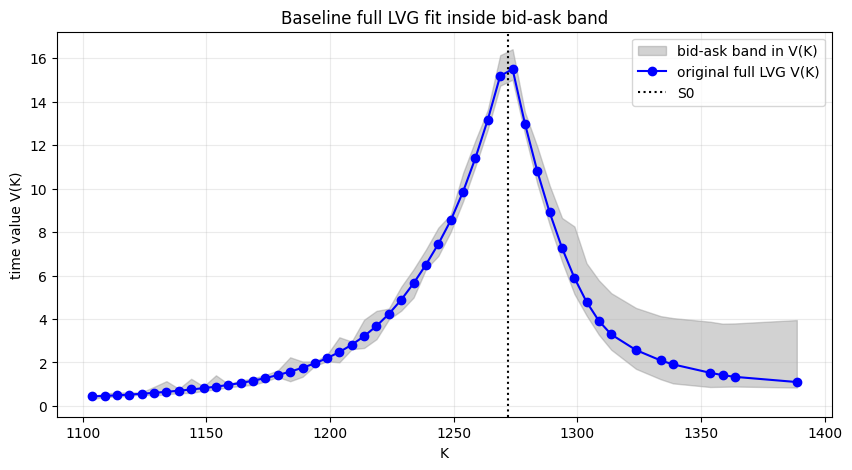

In [29]:
TOL = 1e-8
QUOTE_BUFFER = 1e-6


def to_numpy(x):
    # comnvert torch to numpy
    return x.detach().numpy()


def get_theta_parts(theta):
    # parsing theta into its components
    left_nu = theta[0:R1]
    left_raw_sigma = theta[R1:2 * R1]
    right_nu = theta[2 * R1:2 * R1 + R2]
    right_raw_sigma = theta[2 * R1 + R2:2 * R1 + 2 * R2]

    # softplus(raw_sigma) is always positive, so the LVG diffusion cannot be negative.
    sigma_left = torch.nn.functional.softplus(left_raw_sigma) + 1e-6
    sigma_right = torch.nn.functional.softplus(right_raw_sigma) + 1e-6
    return left_nu, sigma_left, right_nu, sigma_right


def build_lvg_state(theta):
    # builds LVG curve for one theta
    left_nu, sigma_left, right_nu, sigma_right = get_theta_parts(theta)
    left_knots = torch.cat([left_nu, theta.new_tensor([S0])])
    right_knots = torch.cat([theta.new_tensor([S0]), right_nu])

    # Left wing: coefficients are represented at the right endpoint of each interval.
    c_left_unit = []
    dist = left_knots[1] - left_knots[0]
    c_left_unit.append((-torch.exp(-dist / sigma_left[0]), torch.exp(dist / sigma_left[0])))
    for j in range(R1 - 1):
        value = c_left_unit[j][0] + c_left_unit[j][1]
        slope = (-c_left_unit[j][0] + c_left_unit[j][1]) / sigma_left[j]
        dist = left_knots[j + 2] - left_knots[j + 1]
        c_left_unit.append((
            0.5 * (value - sigma_left[j + 1] * slope) * torch.exp(-dist / sigma_left[j + 1]),
            0.5 * (value + sigma_left[j + 1] * slope) * torch.exp(dist / sigma_left[j + 1]),
        ))

    # Right wing: coefficients are represented at the left endpoint of each interval.
    c_right_unit = [None] * R2
    dist = right_knots[-1] - right_knots[-2]
    c_right_unit[-1] = (torch.exp(dist / sigma_right[-1]), -torch.exp(-dist / sigma_right[-1]))
    for j in range(R2 - 1, 0, -1):
        value = c_right_unit[j][0] + c_right_unit[j][1]
        slope = (-c_right_unit[j][0] + c_right_unit[j][1]) / sigma_right[j]
        dist = right_knots[j] - right_knots[j - 1]
        c_right_unit[j - 1] = (
            0.5 * (value - sigma_right[j - 1] * slope) * torch.exp(dist / sigma_right[j - 1]),
            0.5 * (value + sigma_right[j - 1] * slope) * torch.exp(-dist / sigma_right[j - 1]),
        )

    left_value_at_spot = c_left_unit[-1][0] + c_left_unit[-1][1]
    right_value_at_spot = c_right_unit[0][0] + c_right_unit[0][1]
    left_slope_at_spot = (-c_left_unit[-1][0] + c_left_unit[-1][1]) / sigma_left[-1]
    right_slope_at_spot = (-c_right_unit[0][0] + c_right_unit[0][1]) / sigma_right[0]

    denominator = left_slope_at_spot * right_value_at_spot - left_value_at_spot * right_slope_at_spot
    lambda_left = right_value_at_spot / denominator
    lambda_right = left_value_at_spot / denominator
    c_left = []
    for a, b in c_left_unit:
        c_left.append((a * lambda_left, b * lambda_left))
    c_right = []
    for a, b in c_right_unit:
        c_right.append((a * lambda_right, b * lambda_right))

    # calculate_J is the single definition of the smoothness objective.
    J, _, _ = calculate_J(R1, R2, S0, theta)

    return {
        "J": J,
        "lambda_left": lambda_left,
        "lambda_right": lambda_right,
        "left_knots": left_knots,
        "right_knots": right_knots,
        "sigma_left": sigma_left,
        "sigma_right": sigma_right,
        "c_left": c_left,
        "c_right": c_right,
    }


def call_prices_from_state(state, strikes):
    # evaluate the LVG call price formula for a batch of strikes, given the state of the curve.
    strikes = np.asarray(strikes, dtype=float)
    left_knots_np = to_numpy(state["left_knots"])
    right_knots_np = to_numpy(state["right_knots"])
    values = []

    for strike in strikes:
        k = state["left_knots"].new_tensor(float(strike))
        if strike <= S0:
            interval = np.searchsorted(left_knots_np, strike, side="right") - 1
            interval = int(np.clip(interval, 0, len(state["sigma_left"]) - 1))
            dist = state["left_knots"][interval + 1] - k
            time_value = (
                state["c_left"][interval][0] * torch.exp(dist / state["sigma_left"][interval])
                + state["c_left"][interval][1] * torch.exp(-dist / state["sigma_left"][interval])
            )
            values.append(time_value + (S0 - strike))
        else:
            interval = np.searchsorted(right_knots_np, strike, side="right") - 1
            interval = int(np.clip(interval, 0, len(state["sigma_right"]) - 1))
            dist = k - state["right_knots"][interval]
            time_value = (
                state["c_right"][interval][0] * torch.exp(-dist / state["sigma_right"][interval])
                + state["c_right"][interval][1] * torch.exp(dist / state["sigma_right"][interval])
            )
            values.append(time_value)

    return torch.stack(values)


def check_nu_order(nu):
    """The interval knots must move from low strike to high strike."""
    nu_values = to_numpy(nu)
    for i in range(len(nu_values) - 1):
        if nu_values[i + 1] <= nu_values[i]:
            return False
    return True


def check_positive_sigmas(sigmas):
    """A diffusion coefficient must be positive in every interval."""
    sigma_values = to_numpy(sigmas)
    for sigma in sigma_values:
        if sigma <= 0.0:
            return False
    return True


def check_price_bounds(theta):
    # checking that theta produces prices that stay within spread
    state = build_lvg_state(theta)
    model_calls = to_numpy(call_prices_from_state(state, K_q))
    n_below_bid = 0
    n_above_ask = 0
    min_slack = float("inf")
    finite_prices = True

    for i in range(len(K_q)):
        if not np.isfinite(model_calls[i]):
            finite_prices = False
        slack_to_bid = model_calls[i] - bid_q[i]
        slack_to_ask = ask_q[i] - model_calls[i]
        min_slack = min(min_slack, slack_to_bid, slack_to_ask)
        if model_calls[i] < bid_q[i] - TOL:
            n_below_bid += 1
        if model_calls[i] > ask_q[i] + TOL:
            n_above_ask += 1

    inside_spreads = n_below_bid == 0 and n_above_ask == 0
    keeps_buffer = min_slack >= QUOTE_BUFFER - TOL
    return model_calls, n_below_bid, n_above_ask, min_slack, inside_spreads, keeps_buffer, finite_prices

    # we report these outputs so that we don't just simply answer if we stay within spread,
    # but also how close we are to the edges and how many violations we have, for diagnostics

    # this "quote buffer" is to make sure we remain a minimum distance away from all quotes bid/asks
    # but could be adjusted later or removed if we find that optimization implies that some prices lie on the bid/ask
    # constrainsts themselves, which would make sense since some are already very close


def check_static_arbitrage(theta):
    # checking the rest of the conditions of SA
    state = build_lvg_state(theta)
    grid_parts = [np.linspace(0.0, Kbar, 2001), K_q, to_numpy(state["left_knots"]), to_numpy(state["right_knots"])]
    strike_grid = np.unique(np.concatenate(grid_parts))
    call_values = to_numpy(call_prices_from_state(state, strike_grid))

    min_time_value = float("inf")
    finite_static_values = True
    for i in range(len(strike_grid)):
        if not np.isfinite(call_values[i]):
            finite_static_values = False
        intrinsic = max(S0 - strike_grid[i], 0.0)
        time_value = call_values[i] - intrinsic
        min_time_value = min(min_time_value, time_value)

    slopes = []
    for i in range(len(strike_grid) - 1):
        delta_K = strike_grid[i + 1] - strike_grid[i]
        slope = (call_values[i + 1] - call_values[i]) / delta_K
        slopes.append(slope)

    slope_changes = []
    for i in range(len(slopes) - 1):
        slope_changes.append(slopes[i + 1] - slopes[i])

    min_slope = min(slopes)
    max_slope = max(slopes)
    min_slope_change = min(slope_changes)
    positive_time_value = min_time_value >= -TOL
    monotone_calls = max_slope <= TOL
    bounded_slope = min_slope >= -1.0 - TOL and max_slope <= TOL
    convex_calls = min_slope_change >= -TOL
    return finite_static_values, positive_time_value, monotone_calls, bounded_slope, convex_calls, min_time_value, min_slope, max_slope, min_slope_change


def is_theta_feasible(theta):
    # will report a true/false for a condidate theta being feasible within constraints
    # and also return a detailed report of all the checks and relevant metrics for diagnostics

    left_nu, sigma_left, right_nu, sigma_right = get_theta_parts(theta)
    state = build_lvg_state(theta)
    price_results = check_price_bounds(theta)
    static_results = check_static_arbitrage(theta)
    # return tuples, so lines below unpacking for specific metrics and checks 
    model_calls, n_below_bid, n_above_ask, min_slack, inside_spreads, keeps_buffer, finite_prices = price_results
    finite_static, positive_time, monotone, bounded_slope, convex, min_time, min_slope, max_slope, min_change = static_results

    # these just check that everything is finite. For our data this is obvious, but if we want to reuse this code
    # its better to keep it in
    finite_state = bool(np.isfinite(state["J"].item()) and np.isfinite(state["lambda_left"].item()) and np.isfinite(state["lambda_right"].item()))
    positive_lambdas = bool(state["lambda_left"].item() > 0.0 and state["lambda_right"].item() > 0.0)

    # dictionary of all checks, so we report and see which ones fail if any
    checks = {
        "ordered_left_knots": check_nu_order(left_nu),
        "ordered_right_knots": check_nu_order(right_nu),
        "positive_left_sigmas": check_positive_sigmas(sigma_left),
        "positive_right_sigmas": check_positive_sigmas(sigma_right),
        "finite_LVG_state": finite_state,
        "finite_quote_prices": finite_prices,
        "finite_static_grid_prices": finite_static,
        "positive_lambdas": positive_lambdas,
        "inside_bid_ask": inside_spreads,
        "bid_ask_safety_buffer": keeps_buffer,
        "positive_time_value": positive_time,
        "monotone_calls": monotone,
        "convex_calls": convex,
        "slope_between_minus_one_and_zero": bounded_slope,
    }
    is_feasible = all(checks.values())
    report = {
        "state": state, "J": state["J"].item(), "quote_calls": model_calls,
        "checks": checks, "all_constraints_pass": is_feasible,
        "n_below_bid": n_below_bid, "n_above_ask": n_above_ask,
        "min_quote_slack": min_slack, "min_time_value": min_time,
        "min_slope": min_slope, "max_slope": max_slope,
        "min_slope_change": min_change,
    }
    return is_feasible, report


def constraint_summary(report, label):
    rows = []
    for name, passes in report["checks"].items():
        rows.append({"method": label, "check": name, "passes": passes})
    return pd.DataFrame(rows)


baseline_is_feasible, baseline_report = is_theta_feasible(theta_base)
display(constraint_summary(baseline_report, "baseline theta"))
print("Baseline reconstructed J:", baseline_report["J"])
print("Bid violations / ask violations:", baseline_report["n_below_bid"], "/", baseline_report["n_above_ask"])
print("Minimum bid-ask slack:", baseline_report["min_quote_slack"])
print("Minimum time value:", baseline_report["min_time_value"])
print("Slope range:", baseline_report["min_slope"], "to", baseline_report["max_slope"])
print("Minimum convexity slope change:", baseline_report["min_slope_change"])
print("All baseline constraints pass:", baseline_report["all_constraints_pass"])

# Sanity check: the state builder must reproduce the J function used for gradients.
J_check, _, _ = calculate_J(R1, R2, S0, theta_base)
assert np.isclose(J_check.detach().item(), baseline_report["J"], rtol=1e-10, atol=1e-12)

# Show the original feasible LVG fit in time-value coordinates.
intrinsic_q = np.maximum(S0 - K_q, 0.0)
V_bid = bid_q - intrinsic_q
V_ask = ask_q - intrinsic_q
V_baseline = baseline_report["quote_calls"] - intrinsic_q

plt.figure(figsize=(10, 5))
plt.fill_between(K_q, V_bid, V_ask, color="gray", alpha=0.35, label="bid-ask band in V(K)")
plt.plot(K_q, V_baseline, "o-", color="blue", label="original full LVG V(K)")
plt.axvline(S0, color="black", linestyle=":", label="S0")
plt.xlabel("K")
plt.ylabel("time value V(K)")
plt.title("Baseline full LVG fit inside bid-ask band")
plt.grid(True, alpha=0.25)
plt.legend()
plt.show()

## 4. One Constrained Sigma-Gradient Step

PyTorch computes the full derivative

$$\nabla_\theta J(\theta).$$

Because this experiment holds knot locations fixed, the code sets all `nu` components of this gradient to zero. The remaining direction is a sigma-only gradient, denoted here by $\nabla_\sigma J$.

For a trial step size $\alpha$, the code proposes

$$\theta_{\mathrm{new}}=\theta-\alpha\nabla_\sigma J(\theta).$$

The trial point is accepted only if

$$J(\theta_{\mathrm{new}})<J(\theta)$$

and every quote and static-arbitrage feasibility check remains true. If the proposed point fails either condition, the code replaces $\alpha$ with $\alpha/2$ and tries again. This is the backtracking line search in `take_feasible_sigma_step`.

In [30]:
def take_feasible_sigma_step(theta, initial_step=1.0, shrink=0.5, max_trials=25, show_trials=True):
    # IN SIGMA ONLY --- typical GD. We take a step of 1.0, bisecting until acceptance or stopping after 25 tries.
    theta = theta.detach().clone().requires_grad_(True)
    # (above) just makes a fresh copy of theta without modifying the original
    is_feasible, old_report = is_theta_feasible(theta)
    if not is_feasible:
        raise ValueError("The starting theta is not feasible.")

    # 1. Compute J(theta), then ask PyTorch for its gradient.
    J_old = build_lvg_state(theta)["J"]
    J_old.backward()
    grad = theta.grad.clone()

    # 2. The knots nu stay fixed. Only the sigma entries may move.
    # just normalizing the gradient to make step size interpretable. Movements without normalization can be
    # extremely large in comparison to the scale of sigmas, which is why we do this step.
    grad[0:R1] = 0.0
    grad[2 * R1:2 * R1 + R2] = 0.0
    grad_length = torch.linalg.norm(grad).item()
    if grad_length == 0.0:
        return theta, old_report, 0.0, False
    grad = grad / grad_length

    # 3. Try theta_new = theta - step_size * grad.
    step_size = initial_step
    for trial_number in range(1, max_trials + 1):
        # Note: .detach() is important to prevent PyTorch from tracking histiory since we only want
        # to evaluate the current gradient 
        theta_new = theta.detach() - step_size * grad.detach()
        theta_new = theta_new.requires_grad_(True)
        # (above) this step then makes sure we can compute another gradient
        new_is_feasible, new_report = is_theta_feasible(theta_new)
        J_new = new_report["J"]
        improves_J = J_new < old_report["J"]

        if show_trials:
            print("trial", trial_number, "step size =", step_size, "feasible =", new_is_feasible, "J =", J_new)

        # 4. Accept only a feasible step that reduces the jump objective
        if new_is_feasible and improves_J:
            return theta_new, new_report, step_size, True

        # 5. Otherwise try the same direction with a shorter step
        step_size = step_size * shrink

    # If we fail to find an acceptable step after max_trials, return the original theta and report with a flag
    return theta, old_report, 0.0, False


theta_step1, step1_report, step1_size, step1_accepted = take_feasible_sigma_step(theta_base, show_trials=False)
if step1_accepted:
    display(constraint_summary(step1_report, "after one accepted step"))
    print("accepted step size:", step1_size)
    print("J before:", baseline_report["J"])
    print("J after one step:", step1_report["J"])
    print("J improvement:", baseline_report["J"] - step1_report["J"])
    print("Minimum bid-ask slack after step:", step1_report["min_quote_slack"])
else:
    print("No feasible J-decreasing sigma step was found.")

,method,check,passes
0,after one accepted step,ordered_left_knots,True
1,after one accepted step,ordered_right_knots,True
2,after one accepted step,positive_left_sigmas,True
3,after one accepted step,positive_right_sigmas,True
4,after one accepted step,finite_LVG_state,True
5,after one accepted step,finite_quote_prices,True
6,after one accepted step,finite_static_grid_prices,True
7,after one accepted step,positive_lambdas,True
8,after one accepted step,inside_bid_ask,True
9,after one accepted step,bid_ask_safety_buffer,True


accepted step size: 1.0
J before: 0.001252886345895353
J after one step: 0.0011027126363196602
J improvement: 0.00015017370957569288
Minimum bid-ask slack after step: 0.015659415826036138


## 5. Price Impact of One Accepted Step

This plot confirms visually that the accepted smoothness move does not leave the quoted time-value bid-ask band.

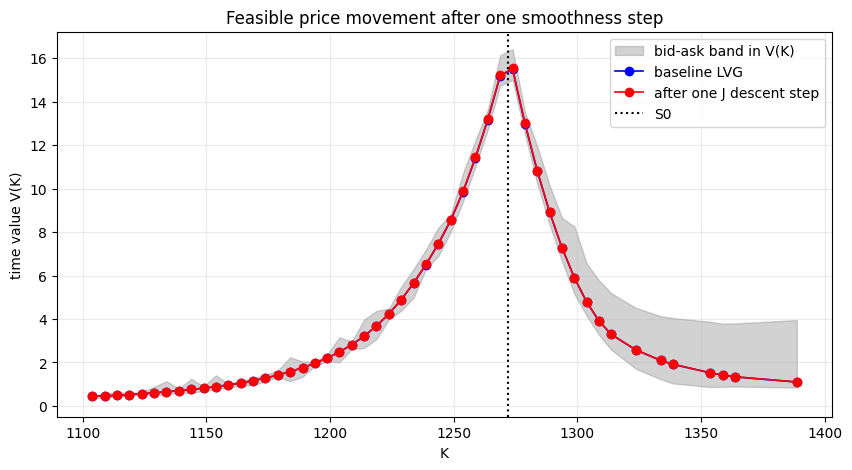

,K,bid,baseline_call,step1_call,ask,price_change
0,1103.9,168.28000,168.413340,168.414341,168.4300,0.001001
1,1108.9,163.39000,163.432125,163.433167,163.5400,0.001042
2,1113.9,158.39000,158.459785,158.460889,158.5900,0.001103
3,1118.9,153.44000,153.493492,153.494671,153.5900,0.001178
4,1123.9,148.50000,148.531876,148.533139,148.6000,0.001264
5,1128.9,143.45000,143.574299,143.575657,143.8500,0.001358
6,1133.9,138.51000,138.620934,138.622397,139.1100,0.001462
7,1138.9,133.56000,133.672071,133.673647,133.7600,0.001576
8,1143.9,128.57000,128.728155,128.729856,129.2200,0.001702
9,1148.9,123.67000,123.790025,123.791865,123.8700,0.001840


In [31]:
if baseline_report["all_constraints_pass"] and step1_report["J"] < baseline_report["J"]:
    intrinsic_q = np.maximum(S0 - K_q, 0.0)
    V_bid = bid_q - intrinsic_q
    V_ask = ask_q - intrinsic_q
    V_base = baseline_report["quote_calls"] - intrinsic_q
    V_step1 = step1_report["quote_calls"] - intrinsic_q

    plt.figure(figsize=(10, 5))
    plt.fill_between(K_q, V_bid, V_ask, color="gray", alpha=0.35, label="bid-ask band in V(K)")
    plt.plot(K_q, V_base, "o-", color="blue", linewidth=1.2, label="baseline LVG")
    plt.plot(K_q, V_step1, "o-", color="red", linewidth=1.2, label="after one J descent step")
    plt.axvline(S0, color="black", linestyle=":", label="S0")
    plt.xlabel("K")
    plt.ylabel("time value V(K)")
    plt.title("Feasible price movement after one smoothness step")
    plt.grid(True, alpha=0.25)
    plt.legend()
    plt.show()

    comparison = pd.DataFrame({
        "K": K_q,
        "bid": bid_q,
        "baseline_call": baseline_report["quote_calls"],
        "step1_call": step1_report["quote_calls"],
        "ask": ask_q,
        "price_change": step1_report["quote_calls"] - baseline_report["quote_calls"],
    })
    display(comparison)
else:
    print("No accepted feasible descent step to plot.")

## 6. Multi-Step Constrained Descent

Starting from the feasible baseline $\theta_0$, repeat the accepted update rule

$$\theta_{n+1}=\theta_n-\alpha_n\nabla_\sigma J(\theta_n).$$

The gradient is recomputed at every accepted iterate, so each step follows the local direction of decreasing curvature jumps from the current curve. The notebook records

- `J_history`: the smoothness objective after each accepted step,
- `step_history`: the accepted $\alpha_n$ values,
- `slack_history`: the smallest remaining distance to a bid or ask boundary,
- `feasible_history`: whether all checks continue to pass.

The loop stops if no feasible improving step is found or if the improvement in `J` becomes negligible. This gives a feasible monotone descent path; it does not by itself prove a global constrained optimum.

In [32]:
theta = theta_base.detach().clone().requires_grad_(True)
is_feasible, current_report = is_theta_feasible(theta)
if not is_feasible:
    raise ValueError("Baseline theta is not feasible, so descent cannot start.")

# Just the optimization history
iteration_history = [0]
J_history = [current_report["J"]]
step_history = [0.0]
feasible_history = [is_feasible]
slack_history = [current_report["min_quote_slack"]]

max_iterations = 50
improvement_tol = 1e-10
stop_reason = "maximum iterations reached"

for iteration in range(1, max_iterations + 1):
    J_old = current_report["J"]
    theta_new, new_report, step_size, accepted = take_feasible_sigma_step(
        theta, initial_step=1.0, shrink=0.5, show_trials=False
    )

    if not accepted:
        stop_reason = "no feasible J-decreasing step found"
        print("iteration", iteration, ": no acceptable step found")
        break

    theta = theta_new
    current_report = new_report
    improvement = J_old - current_report["J"]

    iteration_history.append(iteration)
    J_history.append(current_report["J"])
    step_history.append(step_size)
    feasible_history.append(current_report["all_constraints_pass"])
    slack_history.append(current_report["min_quote_slack"])

    if improvement <= improvement_tol:
        stop_reason = "J improvement below tolerance"
        break

theta_optimized = theta
optimized_report = current_report
optimization_history = pd.DataFrame({
    "iteration": iteration_history,
    "J": J_history,
    "accepted_step_size": step_history,
    "min_quote_slack": slack_history,
    "all_constraints_pass": feasible_history,
})

display(optimization_history)
print("Stop reason:", stop_reason)
print("Accepted iterations:", len(optimization_history) - 1)
print("J before:", baseline_report["J"])
print("J after:", optimized_report["J"])
print("Total J improvement:", baseline_report["J"] - optimized_report["J"])
print("Percent J reduction:", 100.0 * (baseline_report["J"] - optimized_report["J"]) / baseline_report["J"])
print("Final minimum bid-ask slack:", optimized_report["min_quote_slack"])
display(constraint_summary(optimized_report, "optimized theta"))

,iteration,J,accepted_step_size,min_quote_slack,all_constraints_pass
0,0,0.001253,0.000000,0.016660,True
1,1,0.001103,1.000000,0.015659,True
2,2,0.000978,1.000000,0.014696,True
3,3,0.000873,1.000000,0.013765,True
4,4,0.000785,1.000000,0.012859,True
5,5,0.000711,1.000000,0.011974,True
6,6,0.000647,1.000000,0.011106,True
7,7,0.000593,1.000000,0.010253,True
8,8,0.000545,1.000000,0.009410,True
9,9,0.000504,1.000000,0.008578,True


Stop reason: J improvement below tolerance
Accepted iterations: 25
J before: 0.001252886345895353
J after: 0.000290961851068104
Total J improvement: 0.0009619244948272491
Percent J reduction: 76.77667635046552
Final minimum bid-ask slack: 1.0049865259986746e-06


,method,check,passes
0,optimized theta,ordered_left_knots,True
1,optimized theta,ordered_right_knots,True
2,optimized theta,positive_left_sigmas,True
3,optimized theta,positive_right_sigmas,True
4,optimized theta,finite_LVG_state,True
5,optimized theta,finite_quote_prices,True
6,optimized theta,finite_static_grid_prices,True
7,optimized theta,positive_lambdas,True
8,optimized theta,inside_bid_ask,True
9,optimized theta,bid_ask_safety_buffer,True


## 7. Gradient-Descent Diagnostics

The figures below show whether the objective decreased without spending all bid-ask slack, how the diffusion coefficient changed across quoted strikes, and whether the optimized prices visibly remain in the bid-ask band.

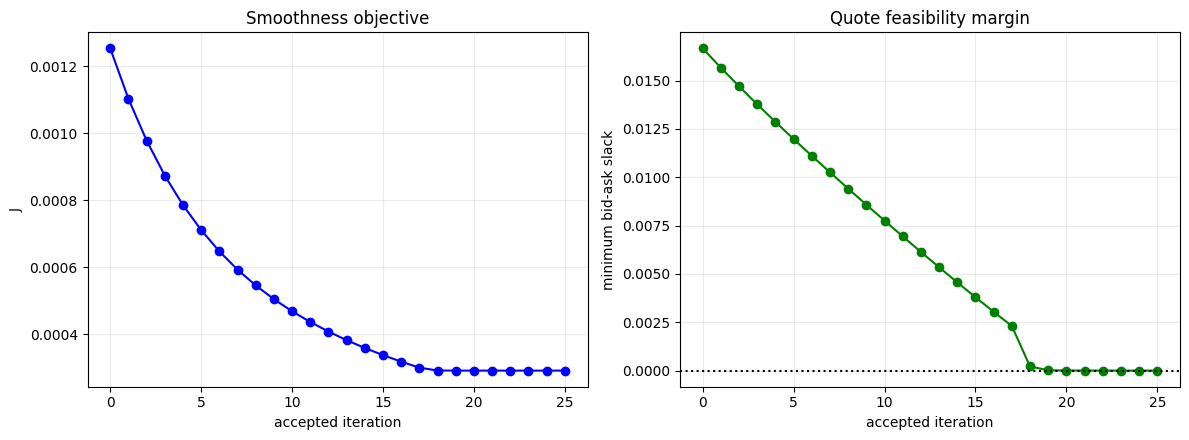

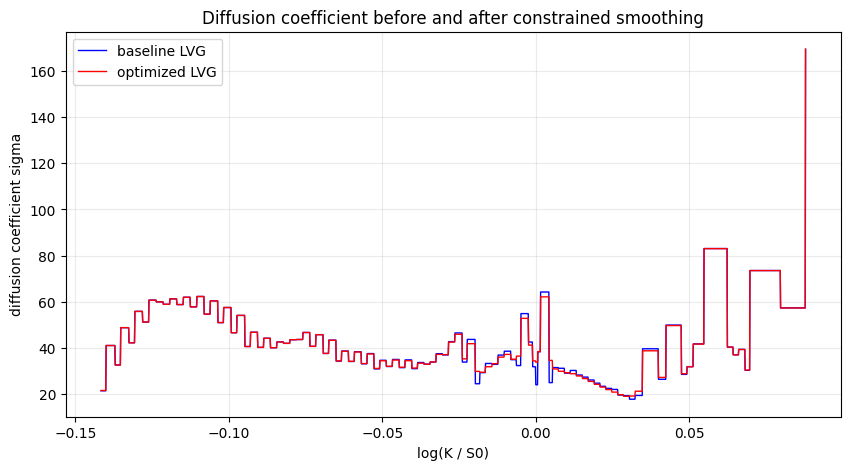

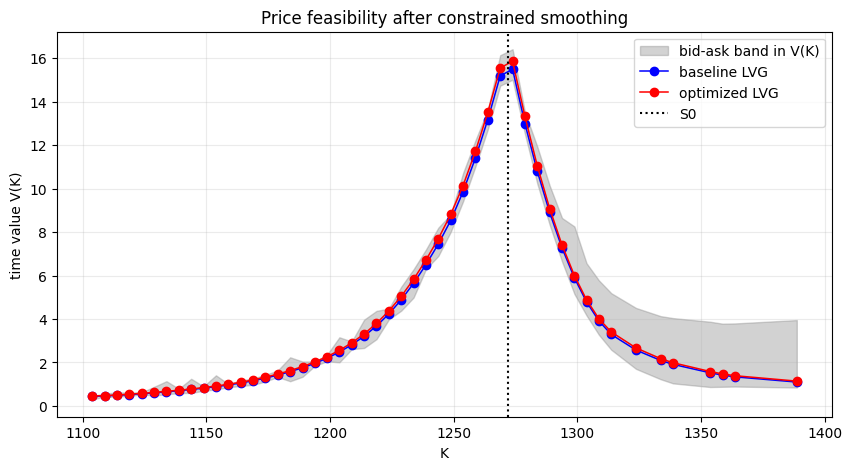

In [33]:
# AI wrote this but I checked it

def sigma_curve_on_grid(state, strike_grid, S0):
    """Read the piecewise constant diffusion coefficient on a strike grid."""
    left_knots = to_numpy(state["left_knots"])
    right_knots = to_numpy(state["right_knots"])
    sigma_left = to_numpy(state["sigma_left"])
    sigma_right = to_numpy(state["sigma_right"])
    curve = np.empty_like(strike_grid, dtype=float)

    for i, strike in enumerate(strike_grid):
        if strike <= S0:
            interval = np.searchsorted(left_knots, strike, side="right") - 1
            interval = int(np.clip(interval, 0, len(sigma_left) - 1))
            curve[i] = sigma_left[interval]
        else:
            interval = np.searchsorted(right_knots, strike, side="right") - 1
            interval = int(np.clip(interval, 0, len(sigma_right) - 1))
            curve[i] = sigma_right[interval]

    return curve


fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(optimization_history["iteration"], optimization_history["J"], "o-", color="blue")
axes[0].set_xlabel("accepted iteration")
axes[0].set_ylabel("J")
axes[0].set_title("Smoothness objective")
axes[0].grid(True, alpha=0.25)
axes[1].plot(optimization_history["iteration"], optimization_history["min_quote_slack"], "o-", color="green")
axes[1].axhline(0.0, color="black", linestyle=":")
axes[1].set_xlabel("accepted iteration")
axes[1].set_ylabel("minimum bid-ask slack")
axes[1].set_title("Quote feasibility margin")
axes[1].grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

K_sigma = np.linspace(K_q.min(), K_q.max(), 2000)
sigma_baseline_curve = sigma_curve_on_grid(baseline_report["state"], K_sigma, S0)
sigma_optimized_curve = sigma_curve_on_grid(optimized_report["state"], K_sigma, S0)

plt.figure(figsize=(10, 5))
plt.plot(np.log(K_sigma / S0), sigma_baseline_curve, color="blue", linewidth=1.0, label="baseline LVG")
plt.plot(np.log(K_sigma / S0), sigma_optimized_curve, color="red", linewidth=1.0, label="optimized LVG")
plt.xlabel("log(K / S0)")
plt.ylabel("diffusion coefficient sigma")
plt.title("Diffusion coefficient before and after constrained smoothing")
plt.grid(True, alpha=0.25)
plt.legend()
plt.show()

intrinsic_q = np.maximum(S0 - K_q, 0.0)
V_bid = bid_q - intrinsic_q
V_ask = ask_q - intrinsic_q
V_baseline = baseline_report["quote_calls"] - intrinsic_q
V_optimized = optimized_report["quote_calls"] - intrinsic_q

plt.figure(figsize=(10, 5))
plt.fill_between(K_q, V_bid, V_ask, color="gray", alpha=0.35, label="bid-ask band in V(K)")
plt.plot(K_q, V_baseline, "o-", color="blue", linewidth=1.1, label="baseline LVG")
plt.plot(K_q, V_optimized, "o-", color="red", linewidth=1.1, label="optimized LVG")
plt.axvline(S0, color="black", linestyle=":", label="S0")
plt.xlabel("K")
plt.ylabel("time value V(K)")
plt.title("Price feasibility after constrained smoothing")
plt.grid(True, alpha=0.25)
plt.legend()
plt.show()

**Interpretation of the feasibility margin.** The minimum slack is the smallest vertical distance from the model call curve to either side of any quoted bid-ask interval. As it approaches the QUOTE_BUFFER, one quote is becoming active: the optimizer has little freedom to move in any direction that pushes that call price farther toward its boundary.

In this run the quote near strike 1248.8 becomes the limiting ask constraint. Gradient descent stops when the additional decrease in J becomes smaller than the improvement tolerance, but that small improvement is closely related to the active quote: the direct descent direction is increasingly blocked by feasibility.

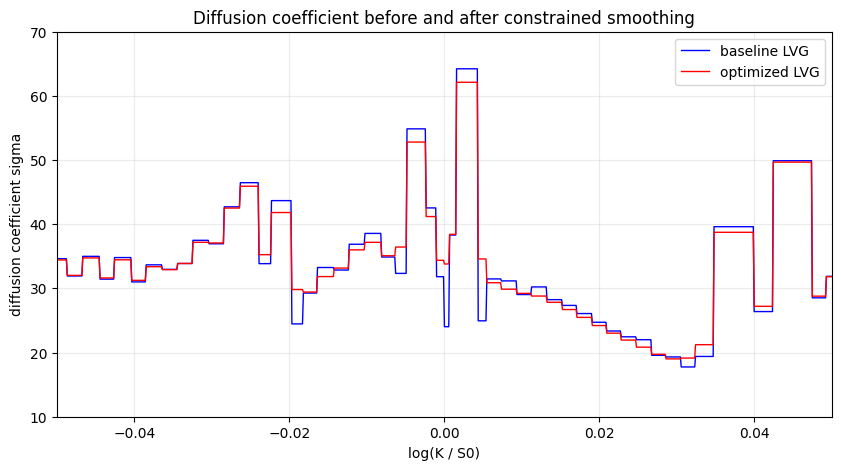

In [34]:
plt.figure(figsize=(10, 5))
plt.plot(np.log(K_sigma / S0), sigma_baseline_curve, color="blue", linewidth=1.0, label="baseline LVG")
plt.plot(np.log(K_sigma / S0), sigma_optimized_curve, color="red", linewidth=1.0, label="optimized LVG")
plt.axis([-0.05, 0.05, 10,70])
plt.xlabel("log(K / S0)")
plt.ylabel("diffusion coefficient sigma")
plt.title("Diffusion coefficient before and after constrained smoothing")
plt.grid(True, alpha=0.25)
plt.legend()
plt.show()

**Diffusion-curve view.** The piecewise values of sigma may look only modestly different after optimization. That is expected because J measures jumps in the reconstructed second derivative C'', not the vertical distance between the two sigma curves. Small coordinated changes in adjacent sigmas can substantially reduce cancellation errors at knots even when the plotted diffusion coefficient remains visually similar.

Baseline J from plotted jumps: 0.0012528863458953537
Optimized J from plotted jumps: 0.0002909618510681039


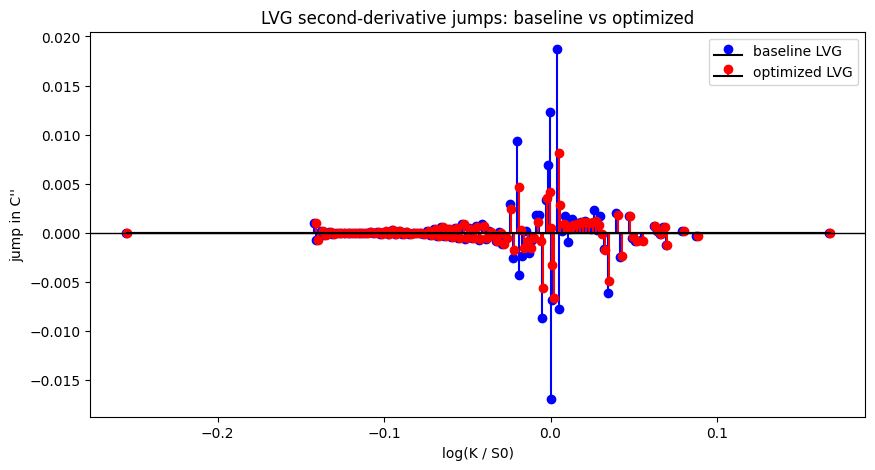

In [35]:
def get_jump_table(theta):
    state = build_lvg_state(theta)

    left_knots = state["left_knots"]
    right_knots = state["right_knots"]
    sigma_left = state["sigma_left"]
    sigma_right = state["sigma_right"]
    c_left = state["c_left"]
    c_right = state["c_right"]

    knots = []
    jumps = []

    # Jumps at internal left-wing knots
    for j in range(R1 - 1):
        knot = left_knots[j + 1]

        second_from_left = (
            c_left[j][0] + c_left[j][1]
        ) / sigma_left[j]**2

        distance = left_knots[j + 2] - left_knots[j + 1]

        second_from_right = (
            c_left[j + 1][0] * torch.exp(distance / sigma_left[j + 1])
            + c_left[j + 1][1] * torch.exp(-distance / sigma_left[j + 1])
        ) / sigma_left[j + 1]**2

        jump = second_from_right - second_from_left

        knots.append(knot.item())
        jumps.append(jump.item())

    # Jump at spot
    second_from_left = (
        c_left[-1][0] + c_left[-1][1]
    ) / sigma_left[-1]**2

    second_from_right = (
        c_right[0][0] + c_right[0][1]
    ) / sigma_right[0]**2

    jump = second_from_right - second_from_left

    knots.append(S0)
    jumps.append(jump.item())

    # Jumps at internal right-wing knots
    for j in range(R2 - 1):
        knot = right_knots[j + 1]
        distance = right_knots[j + 1] - right_knots[j]

        second_from_left = (
            c_right[j][0] * torch.exp(-distance / sigma_right[j])
            + c_right[j][1] * torch.exp(distance / sigma_right[j])
        ) / sigma_right[j]**2

        second_from_right = (
            c_right[j + 1][0] + c_right[j + 1][1]
        ) / sigma_right[j + 1]**2

        jump = second_from_right - second_from_left

        knots.append(knot.item())
        jumps.append(jump.item())

    jump_table = pd.DataFrame({
        "knot": knots,
        "log_moneyness": np.log(np.array(knots) / S0),
        "jump_C_second": jumps
    })

    return jump_table


jumps_baseline = get_jump_table(theta_base)
jumps_optimized = get_jump_table(theta_optimized)

print("Baseline J from plotted jumps:",
      np.sum(jumps_baseline["jump_C_second"]**2))

print("Optimized J from plotted jumps:",
      np.sum(jumps_optimized["jump_C_second"]**2))


plt.figure(figsize=(10, 5))

offset = 0.0005

x_base = jumps_baseline["log_moneyness"] - offset
y_base = jumps_baseline["jump_C_second"]

x_opt = jumps_optimized["log_moneyness"] + offset
y_opt = jumps_optimized["jump_C_second"]

plt.stem(
    x_base,
    y_base,
    linefmt="b-",
    markerfmt="bo",
    basefmt="k-",
    label="baseline LVG"
)

plt.stem(
    x_opt,
    y_opt,
    linefmt="r-",
    markerfmt="ro",
    basefmt="k-",
    label="optimized LVG"
)

plt.axhline(0, color="black", linewidth=1)
plt.xlabel("log(K / S0)")
plt.ylabel("jump in C''")
plt.title("LVG second-derivative jumps: baseline vs optimized")
plt.legend()
plt.show()

**Jump view.** This stem plot displays exactly the quantities being squared and summed in J. The optimized stems are smaller overall, which is the direct visual evidence for the reported decrease in the smoothness objective.

## 8. Why Simple Gradient Descent Stops

At the final gradient-descent iterate, the quote nearest the active ask boundary is identified. The goal of this section is to check whether simple gradient descent stopped because the ordinary smoothness direction is pushing the curve into that nearly active quote boundary.

The important point is that the active call price is a scalar number only after `theta` is fixed. Before `theta` is fixed, it is a scalar-valued function of the model parameters:

$$C_\theta(K_{\mathrm{active}}).$$

The strike $K_{\mathrm{active}}$ is held fixed. PyTorch differentiates with respect to the entries of `theta`, not with respect to strike. Thus

$$\nabla_\theta C_\theta(K_{\mathrm{active}})$$

measures how the active call price would change if each component of `theta` were nudged. Since this notebook keeps all knots fixed, the knot components of this gradient are set to zero, leaving only the sigma-coordinate sensitivity.

The ordinary sigma-only descent direction for reducing the jump objective is

$$d=-\nabla_\sigma J(\theta).$$

For a small step size $\epsilon$, the first-order approximation for the active call price is

$$C_{\theta+\epsilon d}(K_{\mathrm{active}})\approx C_\theta(K_{\mathrm{active}})+\epsilon\,\nabla_\sigma C_\theta(K_{\mathrm{active}})\cdot d.$$

Therefore the dot product

$$\nabla_\sigma C_\theta(K_{\mathrm{active}})\cdot(-\nabla_\sigma J(\theta))$$

tells us whether the $J$-descent direction raises or lowers the active call price. If this value is positive, then moving downhill in $J$ increases the active call price. That is bad when the active quote is already close to the ask. If this value is negative, then moving downhill in $J$ lowers the active call price, which would help with an ask constraint.

This is a diagnostic, not the full optimizer. It checks whether the observed stopping behavior is consistent with the ordinary descent direction running into a bid-ask boundary. The following SLSQP section lets SciPy handle all quote boundaries together.

Note: for options with tighter bid-ask spreads, optimization may be more difficult because the feasible region gives the smoothing step less room to move.

In [36]:
active_index = np.argmin(ask_q - QUOTE_BUFFER - optimized_report["quote_calls"])
K_active = K_q[active_index]

print(K_active)

theta_current = theta_optimized.detach().clone().requires_grad_(True)

J_current = build_lvg_state(theta_current)["J"]
J_current.backward()

grad_J = theta_current.grad.clone()
grad_J[0:R1] = 0.0
grad_J[2 * R1:2 * R1 + R2] = 0.0

print("J at optimized theta:", J_current.item())
print("Sigma-only gradient norm:", torch.linalg.norm(grad_J).item())

1248.8
J at optimized theta: 0.000290961851068104
Sigma-only gradient norm: 1.665742427603109e-05


The norm essentially reports the size of the sigma-gradient. Since it is still positive, we can deduce that J still locally wants to decrease.

In [37]:
# ordinary descent direction for reducing J
ordinary_direction = -grad_J

# compute the gradient of the active call price
theta_price = theta_optimized.detach().clone().requires_grad_(True)

state_price = build_lvg_state(theta_price)
# (below) computes the call price for the active boundary strike
active_call = call_prices_from_state(state_price, [K_active])[0]

# assumes call price is a function of theta, not set yet
active_call.backward()

grad_price = theta_price.grad.clone()

grad_price[0:R1] = 0.0
grad_price[2 * R1:2 * R1 + R2] = 0.0

# this (below) computes the directional derivative of the active call price in the ordinary descent direction for J
price_change_in_descent_direction = torch.dot(
    grad_price, ordinary_direction
).item()

print("Call price at active strike:", active_call.item())
print("Ask at active strike:", ask_q[active_index])
print("First-order active-call change in ordinary descent direction:",
      price_change_in_descent_direction)

Call price at active strike: 31.879998995013473
Ask at active strike: 31.88
First-order active-call change in ordinary descent direction: 2.1165264992299088e-07


Since the first-order change is positive, this proves what we thought. The current J minimizingf direction pushes positively into the current call price, which would take us outside the bid-ask constraint.

The projected direction below removes the first-order component that pushes through this active quote. This is a diagnostic calculation; the formal constrained optimization in the following section lets SciPy handle all quote boundaries together.

In [38]:
# Remove the part of the smoothing direction that pushes through the active ask.
projection_amount = torch.dot(ordinary_direction, grad_price) / torch.dot(grad_price, grad_price)

projected_direction = ordinary_direction - projection_amount * grad_price

# Normalize so step sizes are easy to interpret.
projected_norm = torch.linalg.norm(projected_direction).item()
projected_direction = projected_direction / projected_norm

J_change_in_projected_direction = torch.dot(grad_J, projected_direction).item()
price_change_in_projected_direction = torch.dot(grad_price, projected_direction).item()

print("Projected direction norm before normalization:", projected_norm)
print("First-order J change in projected direction:", J_change_in_projected_direction)
print("First-order active-call change in projected direction:", price_change_in_projected_direction)

Projected direction norm before normalization: 1.639717980544545e-05
First-order J change in projected direction: -1.6397179805445454e-05
First-order active-call change in projected direction: -2.6020852139652106e-18


**Interpretation.** This projection removes the part of the ordinary smoothness direction that would push through the active ask constraint.

The projected direction still has nonzero size, so the active quote does not block every possible smoothing direction.

The first-order change in J is negative, which means this projected direction should still reduce the jump objective locally.

The first-order change in the active call price is essentially zero, which means this direction is approximately tangent to the active ask boundary.

So this diagnostic suggests that simple gradient descent stops because its naive descent direction runs into a quote boundary, not because no further smoothing direction exists. This is why the next step uses SLSQP, which handles all bid-ask constraints at once.

## 9. Constrained Minimization with SLSQP

Backtracking gradient descent follows one local descent direction at a time. To test whether additional feasible improvement exists, we now use `scipy.optimize.minimize` with SLSQP. The variables remain only the raw sigma coordinates; every nu remains fixed. The inequality constraints supplied to SLSQP are the bid-ask rooms

$$C_\theta(K_i)-(\text{bid}_i+\varepsilon)\geq 0,\qquad (\text{ask}_i-\varepsilon)-C_\theta(K_i)\geq 0.$$

This is the constrained problem

$$\min_{s_L,s_R} J(\nu_L,s_L,\nu_R,s_R)$$

subject to the quote inequalities above, where the physical sigmas remain positive because

$$\sigma=\operatorname{softplus}(s)+10^{-6}.$$

objective_with_gradient returns $J$ and its sigma derivative to SciPy. quote_constraint_values returns the remaining room above each bid and below each ask. quote_constraint_jacobian supplies the derivative of each quote room with respect to every sigma parameter.

The first solve begins from the feasible gradient-descent result. Afterwards we repeat the same constrained solve from the original baseline to check whether the starting point changes the outcome.

In [39]:
theta_fixed = theta_optimized.detach().clone()

# Extract the current raw sigma variables from theta_optimized.
raw_sigma_start = torch.cat([
    theta_fixed[R1:2 * R1],
    theta_fixed[2 * R1 + R2:2 * R1 + 2 * R2]
]).numpy()


def build_theta_from_raw_sigmas(raw_sigma_values):
    raw_sigma = torch.tensor(
        raw_sigma_values,
        dtype=torch.float64,
        requires_grad=True
    )

    raw_sigma_left = raw_sigma[0:R1]
    raw_sigma_right = raw_sigma[R1:R1 + R2]

    theta = torch.cat([
        theta_fixed[0:R1],                         # fixed left nus
        raw_sigma_left,                            # variable left sigmas
        theta_fixed[2 * R1:2 * R1 + R2],          # fixed right nus
        raw_sigma_right                            # variable right sigmas
    ])

    return theta, raw_sigma


# objective function for SciPy that minimizes J
def objective_with_gradient(raw_sigma_values):
    theta, raw_sigma = build_theta_from_raw_sigmas(raw_sigma_values)

    J = build_lvg_state(theta)["J"]
    J.backward()

    gradient = raw_sigma.grad.detach().numpy()

    return J.item(), gradient


# bid ask constraints for oiptimizer, with form constraint >= 0

def quote_constraint_values(raw_sigma_values):
    theta, raw_sigma = build_theta_from_raw_sigmas(raw_sigma_values)

    state = build_lvg_state(theta)
    model_calls = call_prices_from_state(state, K_q)

    bid_limits = torch.tensor(bid_q + QUOTE_BUFFER, dtype=torch.float64)
    ask_limits = torch.tensor(ask_q - QUOTE_BUFFER, dtype=torch.float64)

    room_above_bid = model_calls - bid_limits
    room_below_ask = ask_limits - model_calls

    constraints = torch.cat([room_above_bid, room_below_ask])

    return constraints.detach().numpy()


def quote_constraint_jacobian(raw_sigma_values):
    # derivative of every quote constraint (like we did above for the active boundary) 
    # but now for every quote and for all raw sigma variables, using PyTorch autograd 
    # to get the Jacobian matrix of all constraints with respect to all raw sigma variables.
    raw_sigma = torch.tensor(
        raw_sigma_values,
        dtype=torch.float64,
        requires_grad=True
    )

    def model_calls_from_raw_sigma(raw_values):
        # maps sigmas to model call prices at strikes
        raw_sigma_left = raw_values[0:R1]
        raw_sigma_right = raw_values[R1:R1 + R2]

        theta = torch.cat([
            theta_fixed[0:R1],
            raw_sigma_left,
            theta_fixed[2 * R1:2 * R1 + R2],
            raw_sigma_right
        ])

        state = build_lvg_state(theta)
        return call_prices_from_state(state, K_q)

    price_jacobian = torch.autograd.functional.jacobian(
        model_calls_from_raw_sigma,
        raw_sigma
    ).detach().numpy()

    # Bid room:
    #     g_bid_i = C_theta(K_i) - (bid_i + epsilon)
    # so its derivative with respect to the raw sigma variables is
    #     grad g_bid_i = grad C_theta(K_i)
    #
    # Ask room:
    #     g_ask_i = (ask_i - epsilon) - C_theta(K_i)
    # so its derivative with respect to the raw sigma variables is
    #     grad g_ask_i = -grad C_theta(K_i)

    constraint_jacobian = np.vstack([
        price_jacobian,
        -price_jacobian
    ])
    # stacks them vertically in the same style as we stacked the constraints themselves, 
    # so the order of rows in the Jacobian matches the order of constraints
    # *SLSQP wants one list of all constrained values*

    return constraint_jacobian


quote_constraints = {
    "type": "ineq",
    "fun": quote_constraint_values,
    "jac": quote_constraint_jacobian
}


# printing progress callback for optimizer, to see how J and constraint room evolve during optimization
iteration_number = 0

def print_progress(raw_sigma_values):
    global iteration_number

    iteration_number += 1
    J_value, gradient = objective_with_gradient(raw_sigma_values)
    minimum_constraint_room = quote_constraint_values(raw_sigma_values).min()

    print(
        "iteration", iteration_number,
        ": J =", J_value,
        "minimum constraint room =", minimum_constraint_room
    )


# run optimization

print("Starting J:", optimized_report["J"])
print("Starting minimum quote slack:", optimized_report["min_quote_slack"])

result = minimize(
    fun=objective_with_gradient,
    x0=raw_sigma_start,
    jac=True,
    method="SLSQP",
    constraints=[quote_constraints],
    callback=print_progress,
    options={
        "maxiter": 100,
        "ftol": 1e-12,
        "disp": True
    }
)

print()
print("SciPy success:", result.success)
print("SciPy message:", result.message)
print("SciPy iterations:", result.nit)
print("SciPy final J:", result.fun)


# rebuild final theta and run diagnostics

theta_scipy, raw_sigma_final = build_theta_from_raw_sigmas(result.x)
theta_scipy = theta_scipy.detach().clone().requires_grad_(True)

scipy_is_feasible, scipy_report = is_theta_feasible(
    theta_scipy,
)

print()
print("Previous GD J:", optimized_report["J"])
print("SciPy constrained J:", scipy_report["J"])
print("Additional J improvement:", optimized_report["J"] - scipy_report["J"])
print("Percent improvement beyond GD:",
      100.0 * (optimized_report["J"] - scipy_report["J"]) / optimized_report["J"])
print("Final minimum quote slack:", scipy_report["min_quote_slack"])
print("All full diagnostic constraints pass:", scipy_is_feasible)

Starting J: 0.000290961851068104
Starting minimum quote slack: 1.0049865259986746e-06
iteration 1 : J = 0.0002909615819980929 minimum constraint room = 9.947598300641403e-14
iteration 2 : J = 0.00029096023776331917 minimum constraint room = 2.6574298317427747e-12
iteration 3 : J = 0.0002909535167507087 minimum constraint room = 6.617995040869573e-11
iteration 4 : J = 0.0002909199157189372 minimum constraint room = 1.6543388881018473e-09
iteration 5 : J = 0.0002907520113584043 minimum constraint room = 4.134301434532972e-08
iteration 6 : J = 0.00028991503182260013 minimum constraint room = 1.2653219485514455e-06
iteration 7 : J = 0.0002857932430532341 minimum constraint room = 3.803827198112231e-05
iteration 8 : J = 0.0002666817404681439 minimum constraint room = 0.0009521102239631318
iteration 9 : J = 0.00020047932447299485 minimum constraint room = 0.0035419020753693076
iteration 10 : J = 0.00015069685191498923 minimum constraint room = 0.008425155117748773
iteration 11 : J = 0.000146

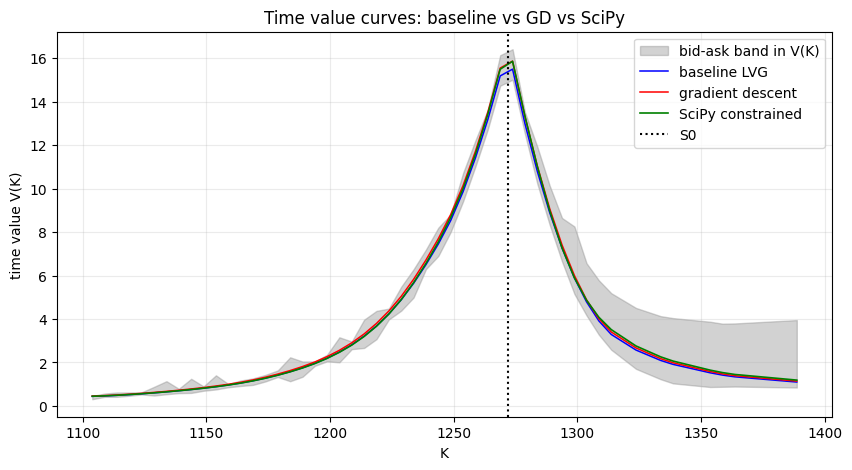

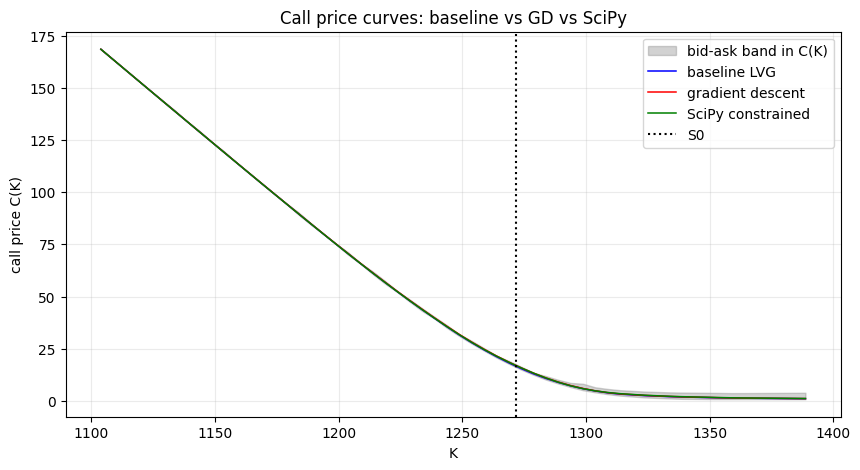

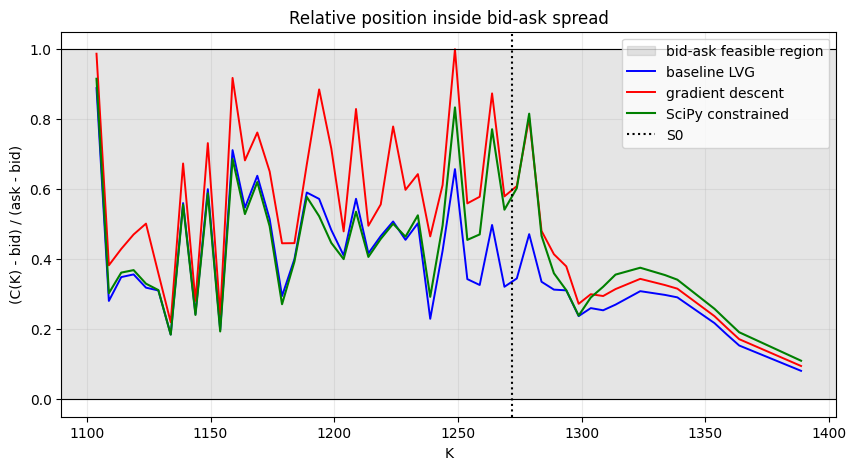

In [40]:
# Codex wrote this
# Compare time-value curves after SciPy optimization.
intrinsic_q = np.maximum(S0 - K_q, 0.0)

V_bid = bid_q - intrinsic_q
V_ask = ask_q - intrinsic_q

V_baseline = baseline_report["quote_calls"] - intrinsic_q
V_gd = optimized_report["quote_calls"] - intrinsic_q
V_scipy = scipy_report["quote_calls"] - intrinsic_q

plt.figure(figsize=(10, 5))
plt.fill_between(K_q, V_bid, V_ask, color="gray", alpha=0.35, label="bid-ask band in V(K)")
plt.plot(K_q, V_baseline, "-", color="blue", linewidth=1.1, label="baseline LVG")
plt.plot(K_q, V_gd, "-", color="red", linewidth=1.1, label="gradient descent")
plt.plot(K_q, V_scipy, "-", color="green", linewidth=1.2, label="SciPy constrained")
plt.axvline(S0, color="black", linestyle=":", label="S0")
plt.xlabel("K")
plt.ylabel("time value V(K)")
plt.title("Time value curves: baseline vs GD vs SciPy")
plt.grid(True, alpha=0.25)
plt.legend()
plt.show()


# Compare call-price curves after SciPy optimization.
plt.figure(figsize=(10, 5))
plt.fill_between(K_q, bid_q, ask_q, color="gray", alpha=0.35, label="bid-ask band in C(K)")
plt.plot(K_q, baseline_report["quote_calls"], "-", color="blue", linewidth=1.1, label="baseline LVG")
plt.plot(K_q, optimized_report["quote_calls"], "-", color="red", linewidth=1.1, label="gradient descent")
plt.plot(K_q, scipy_report["quote_calls"], "-", color="green", linewidth=1.1, label="SciPy constrained")
plt.axvline(S0, color="black", linestyle=":", label="S0")
plt.xlabel("K")
plt.ylabel("call price C(K)")
plt.title("Call price curves: baseline vs GD vs SciPy")
plt.grid(True, alpha=0.25)
plt.legend()
plt.show()

# AI wrote this relative graph but it helps to see how close we are to the edges of the bid-ask spread,
# since being close to the edge is riskier in terms of feasibility if we take another step that moves prices
spread_q = ask_q - bid_q

z_baseline = (baseline_report["quote_calls"] - bid_q) / spread_q
z_gd = (optimized_report["quote_calls"] - bid_q) / spread_q
z_scipy = (scipy_report["quote_calls"] - bid_q) / spread_q

plt.figure(figsize=(10, 5))
plt.axhspan(0, 1, color="gray", alpha=0.2, label="bid-ask feasible region")
plt.plot(K_q, z_baseline, "-", color="blue", linewidth=1.4, label="baseline LVG")
plt.plot(K_q, z_gd, "-", color="red", linewidth=1.4, label="gradient descent")
plt.plot(K_q, z_scipy, "-", color="green", linewidth=1.5, label="SciPy constrained")
plt.axhline(0, color="black", linewidth=0.8)
plt.axhline(1, color="black", linewidth=0.8)
plt.axvline(S0, color="black", linestyle=":", label="S0")
plt.xlabel("K")
plt.ylabel("(C(K) - bid) / (ask - bid)")
plt.title("Relative position inside bid-ask spread")
plt.grid(True, alpha=0.25)
plt.legend()
plt.show()

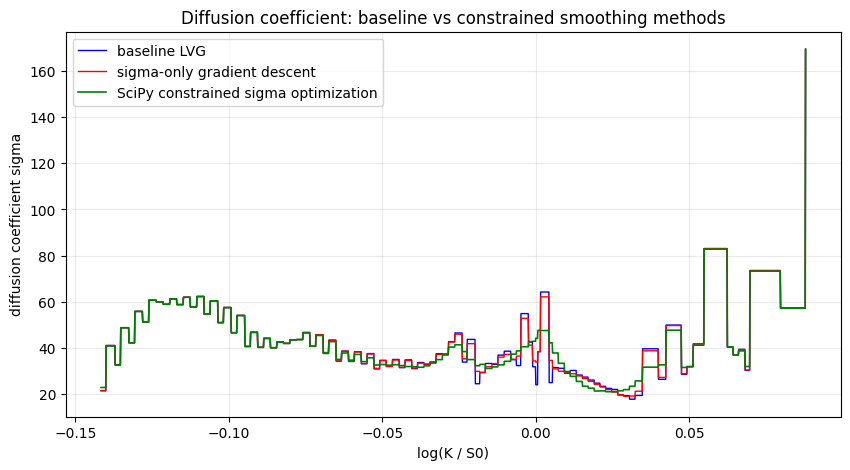

In [41]:
# build the diffusion coefficient curve for the SciPy-constrained solution.
sigma_scipy_curve = sigma_curve_on_grid(
    scipy_report["state"],
    K_sigma,
    S0
)

plt.figure(figsize=(10, 5))

plt.plot(
    np.log(K_sigma / S0),
    sigma_baseline_curve,
    color="blue",
    linewidth=1.0,
    label="baseline LVG"
)

plt.plot(
    np.log(K_sigma / S0),
    sigma_optimized_curve,
    color="red",
    linewidth=1.0,
    label="sigma-only gradient descent"
)

plt.plot(
    np.log(K_sigma / S0),
    sigma_scipy_curve,
    color="green",
    linewidth=1.2,
    label="SciPy constrained sigma optimization"
)

plt.xlabel("log(K / S0)")
plt.ylabel("diffusion coefficient sigma")
plt.title("Diffusion coefficient: baseline vs constrained smoothing methods")
plt.grid(True, alpha=0.25)
plt.legend()
plt.show()

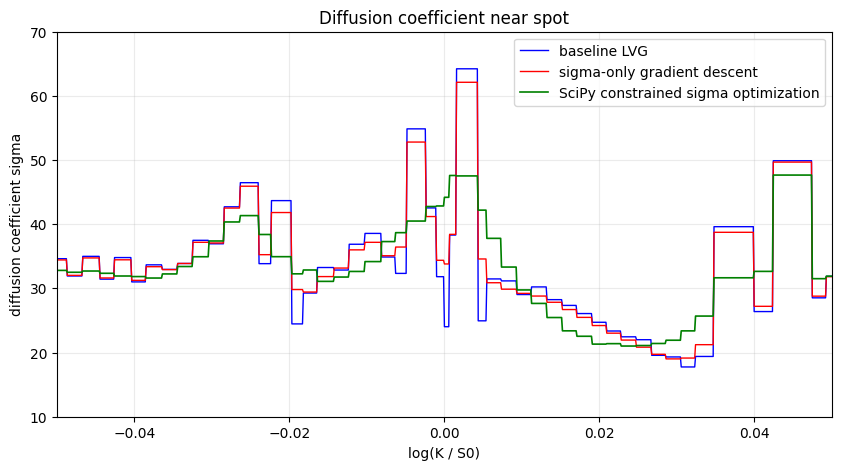

In [42]:
# zoomed-in figure from above near strike
plt.figure(figsize=(10, 5))

plt.plot(
    np.log(K_sigma / S0),
    sigma_baseline_curve,
    color="blue",
    linewidth=1.0,
    label="baseline LVG"
)

plt.plot(
    np.log(K_sigma / S0),
    sigma_optimized_curve,
    color="red",
    linewidth=1.0,
    label="sigma-only gradient descent"
)

plt.plot(
    np.log(K_sigma / S0),
    sigma_scipy_curve,
    color="green",
    linewidth=1.2,
    label="SciPy constrained sigma optimization"
)

plt.axis([-0.05, 0.05, 10, 70])
plt.xlabel("log(K / S0)")
plt.ylabel("diffusion coefficient sigma")
plt.title("Diffusion coefficient near spot")
plt.grid(True, alpha=0.25)
plt.legend()
plt.show()

## 10. Starting-Point Check

A nonlinear constrained optimizer can converge to different local solutions from different feasible starting points. This repeat solve uses exactly the same fixed-nu problem but starts directly from the original LVG theta rather than the gradient-descent theta. Similar final J values would support, but not prove, that both paths have found the same local basin.

In [43]:
# here I reuse the helper functions from section 9 for the baseline LVG theta for comparison
theta_fixed = theta_base.detach().clone()

raw_sigma_start_baseline = torch.cat([
    theta_fixed[R1:2 * R1],
    theta_fixed[2 * R1 + R2:2 * R1 + 2 * R2]
]).numpy()

baseline_start_feasible, baseline_start_initial_report = is_theta_feasible(theta_base)

print("Starting from original LVG theta")
print("Starting J:", baseline_start_initial_report["J"])
print("Starting minimum quote slack:", baseline_start_initial_report["min_quote_slack"])
print("Starting theta feasible:", baseline_start_feasible)

# reset the progress counter used by print_progress.
iteration_number = 0

result_from_baseline = minimize(
    fun=objective_with_gradient,
    x0=raw_sigma_start_baseline,
    jac=True,
    method="SLSQP",
    constraints=[quote_constraints],
    callback=print_progress,
    options={
        "maxiter": 100,
        "ftol": 1e-12,
        "disp": True
    }
)

# rebuild the full theta from the optimized raw sigmas.
# this uses the same build_theta_from_raw_sigmas function as Section 9,
# but now theta_fixed is the original LVG baseline theta.
theta_scipy_from_baseline, _ = build_theta_from_raw_sigmas(result_from_baseline.x)
theta_scipy_from_baseline = theta_scipy_from_baseline.detach().clone().requires_grad_(True)

baseline_start_final_feasible, baseline_start_report = is_theta_feasible(
    theta_scipy_from_baseline,
)

print()
print("SciPy success:", result_from_baseline.success)
print("SciPy message:", result_from_baseline.message)
print("SciPy iterations:", result_from_baseline.nit)

print()
print("Original LVG J:", baseline_report["J"])
print("Baseline-start SciPy J:", baseline_start_report["J"])
print("J reduction from original LVG:", baseline_report["J"] - baseline_start_report["J"])
print("Percent J reduction from original LVG:",
      100.0 * (baseline_report["J"] - baseline_start_report["J"])
      / baseline_report["J"])

print()
print("Final minimum quote slack:", baseline_start_report["min_quote_slack"])
print("All full diagnostic constraints pass:", baseline_start_final_feasible)


Starting from original LVG theta
Starting J: 0.001252886345895353
Starting minimum quote slack: 0.016660066938356977
Starting theta feasible: True
iteration 1 : J = 0.0012528591400319436 minimum constraint room = 0.01665889431569667
iteration 2 : J = 0.0012527231278481373 minimum constraint room = 0.016658031261982842
iteration 3 : J = 0.0012520434950315708 minimum constraint room = 0.016653717608420493
iteration 4 : J = 0.001248656005283409 minimum constraint room = 0.016632190284298076
iteration 5 : J = 0.001231981935050849 minimum constraint room = 0.016525571674407047
iteration 6 : J = 0.0011547857966649057 minimum constraint room = 0.016016890452704047
iteration 7 : J = 0.0008838445185654708 minimum constraint room = 0.013974669399146933
iteration 8 : J = 0.0006141066861563729 minimum constraint room = 0.0111653012334898
iteration 9 : J = 0.000522203169122288 minimum constraint room = 0.00964807414874258
iteration 10 : J = 0.00048786556061556773 minimum constraint room = 0.0086705

In [44]:
J_from_baseline = baseline_start_report["J"]
J_from_GD = scipy_report["J"]

absolute_difference = abs(J_from_baseline - J_from_GD)

print("SciPy J starting from original LVG:", J_from_baseline)
print("SciPy J starting from gradient descent:", J_from_GD)
print("Absolute difference in J:", absolute_difference)

SciPy J starting from original LVG: 9.99322155133435e-05
SciPy J starting from gradient descent: 6.289864093482685e-05
Absolute difference in J: 3.703357457851665e-05


## Conclusion

The original LVG curve satisfies all checked bid-ask and static-arbitrage conditions, but its curvature-jump objective is J = 0.0012528863. Keeping every knot location fixed and changing only the positive diffusion coefficients substantially reduces those second-derivative jumps while preserving the constraints.

The simple feasible gradient-descent run reduced the objective to J = 0.0002909619. During this path the ask bound near K = 1248.8 became active, showing that the direct local descent direction was constrained by the quote band.

SLSQP then improved the solution further by moving the sigma coordinates jointly subject to the same bid-ask constraints. Starting from the original LVG parameters, it reached J = 9.9932e-05, a 92.02% decrease from baseline, and remained feasible with minimum quote slack approximately 1.06e-06. Starting from the gradient-descent result, it reached the lower value J = 6.2899e-05, a 94.98% decrease from baseline, and remained feasible with minimum quote slack approximately 0.01266.

The two SLSQP runs therefore produce materially different feasible objective values: the gradient-descent initialization finishes with J about 37.06% lower than the original-LVG initialization. This demonstrates meaningful start-point sensitivity in the constrained numerical search and supports using multiple initializations when evaluating smoother LVG parameter sets.

Both SLSQP runs ended because the 100-iteration limit was reached, not because convergence was certified. The results show feasible and substantial smoothing improvement, but they do not yet prove that either point is a local minimum, that the two endpoints belong to distinct local basins, or that a global constrained minimum has been found.